In [8]:
!pip install sqlalchemy psycopg2-binary


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import glob

# 1. Extract the specific Extended History files
files = []
for year in range(2022, 2027):
    # The wildcard (*) catches any extra numbers Spotify adds to the end of the filename
    files.extend(glob.glob(f'Streaming_History_Audio_{year}*.json'))

# Remove any accidental duplicates just in case
files = list(set(files))

if not files:
    print("Error: I still can't find the files. Make sure this notebook is saved in the exact same folder as your unzipped Spotify data!")
else:
    print(f"Found {len(files)} files to process.")
    
    # Read and combine all files into one master DataFrame
    df = pd.concat([pd.read_json(f) for f in files], ignore_index=True)

    # 2. Transform Timezone 
    # Extended history uses 'ts'. We convert it to your local time (Africa/Harare)
    df['played_at'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('Africa/Harare')

    # 3. Transform Data Types 
    df['minutes_played'] = df['ms_played'] / 60000

    # 4. Filter Noise (The 30-second rule to remove skipped songs)
    df_clean = df[df['ms_played'] >= 30000].copy()

    # 5. Format for PostgreSQL
    # Rename Spotify's extremely long column names into a clean SQL schema
    df_clean = df_clean.rename(columns={
        'master_metadata_album_artist_name': 'artist_name',
        'master_metadata_track_name': 'track_name'
    })
    
    # Keep only the columns we actually care about, dropping IPs and device IDs
    df_clean = df_clean[['played_at', 'artist_name', 'track_name', 'minutes_played', 'ms_played']]

    # Drop rows where the track name or artist is null (this usually happens with Podcasts)
    df_clean = df_clean.dropna(subset=['track_name', 'artist_name'])

    print(f"Success! {len(df_clean)} rows perfectly cleaned and ready for the database.")
    
    # Show a quick preview of the final data
    display(df_clean.head())

Found 5 files to process.
Success! 12428 rows perfectly cleaned and ready for the database.


,played_at,artist_name,track_name,minutes_played,ms_played
0,2026-01-04 21:37:31+02:00,Justin Woodlake,Munoziva Kusasimba Kwangu,2.233333,134000
1,2026-01-05 07:08:49+02:00,Nathaniel Bassey,Iba,6.043900,362634
2,2026-01-05 07:18:04+02:00,Nathaniel Bassey,Jesus Iye,8.763583,525815
3,2026-01-05 07:32:49+02:00,Nathaniel Bassey,Adonai,4.727133,283628
4,2026-01-05 17:16:10+02:00,Nelly,Dilemma,4.819333,289160


In [12]:
# 1. Convert the dates to simple strings (CSV format prefers this to prevent timezone errors)
df_clean['played_at'] = df_clean['played_at'].astype(str)

# 2. Save your clean data directly to your computer
file_name = "clean_spotify_history.csv"
df_clean.to_csv(file_name, index=False)

print(f"File saved successfully!")
print(f"Look in your current folder for a file named: {file_name}")

File saved successfully!
Look in your current folder for a file named: clean_spotify_history.csv


Detected 22 'Deep Work' sessions since 2022.


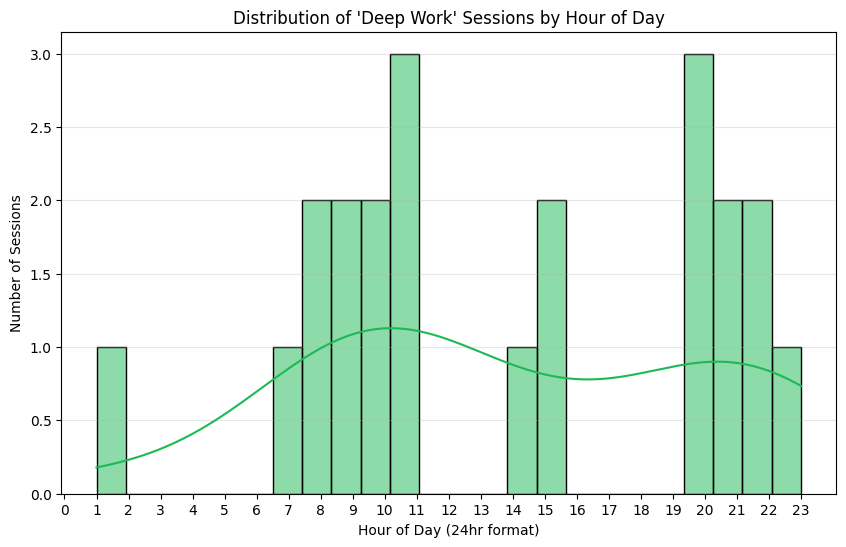

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FIX THE DATA TYPE (Crucial step)
# This converts the strings back into actual timestamps
df_clean['played_at'] = pd.to_datetime(df_clean['played_at'])

# 2. SORT & CALCULATE GAPS
# We sort by time to make sure we are measuring gaps between consecutive songs
df_clean = df_clean.sort_values('played_at')
df_clean['gap'] = df_clean['played_at'].diff().dt.total_seconds() / 60

# 3. IDENTIFY SESSIONS
# We define a "new session" as any gap longer than 15 minutes
df_clean['new_session'] = df_clean['gap'] > 15
df_clean['session_id'] = df_clean['new_session'].cumsum()

# 4. AGGREGATE DEEP WORK
# Find sessions longer than 2 hours (120 minutes)
session_analysis = df_clean.groupby('session_id').agg({
    'minutes_played': 'sum',
    'played_at': 'min'
})

deep_work = session_analysis[session_analysis['minutes_played'] >= 120].copy()
deep_work['hour'] = deep_work['played_at'].dt.hour

print(f"Detected {len(deep_work)} 'Deep Work' sessions since 2022.")

# 5. VISUALIZE: When do you code/study most?
plt.figure(figsize=(10, 6))
sns.histplot(deep_work['hour'], bins=24, kde=True, color='#1DB954')
plt.title("Distribution of 'Deep Work' Sessions by Hour of Day")
plt.xlabel("Hour of Day (24hr format)")
plt.ylabel("Number of Sessions")
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [17]:
# --- A. ANCHOR ARTISTS ---
top_2022 = df_clean[df_clean['played_at'].dt.year == 2022].groupby('artist_name')['minutes_played'].sum().nlargest(20).index
top_2026 = df_clean[df_clean['played_at'].dt.year == 2026].groupby('artist_name')['minutes_played'].sum().nlargest(20).index

anchors = set(top_2022).intersection(set(top_2026))
print(f"Your 'Anchor' Artists (Top 20 in both 2022 and 2026): {anchors}")

# --- B. DISCOVERY RATE ---
discovery_rate = df_clean.groupby(df_clean['played_at'].dt.year)['artist_name'].nunique()
print("\nUnique Artists per Year:")
print(discovery_rate)

Your 'Anchor' Artists (Top 20 in both 2022 and 2026): {'Maroon 5', 'Minister Michael Mahendere'}

Unique Artists per Year:
played_at
2022    204
2023     89
2024    824
2025    792
2026    456
Name: artist_name, dtype: int64


In [18]:
# Assuming df_clean is sorted by time
df_clean['is_skip'] = df_clean['ms_played'] < 30000 
df_clean['new_session'] = (df_clean['played_at'].diff().dt.total_seconds() / 60) > 15
df_clean['session_id'] = df_clean['new_session'].cumsum()

# Filter for sessions with 0 skips and > 120 mins
session_stats = df_clean.groupby('session_id').agg(
    total_mins=('minutes_played', 'sum'),
    skips=('is_skip', 'sum'),
    start_time=('played_at', 'min')
)

deep_work = session_stats[(session_stats['total_mins'] >= 120) & (session_stats['skips'] == 0)]
print(f"Deep Work Sessions Found: {len(deep_work)}")
# To find the '2 AM' trend: deep_work['start_time'].dt.hour.value_counts()

Deep Work Sessions Found: 22


C:\Users\DELL\AppData\Local\Temp\ipykernel_6356\4101939262.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['month_year'] = df_clean['played_at'].dt.to_period('M')


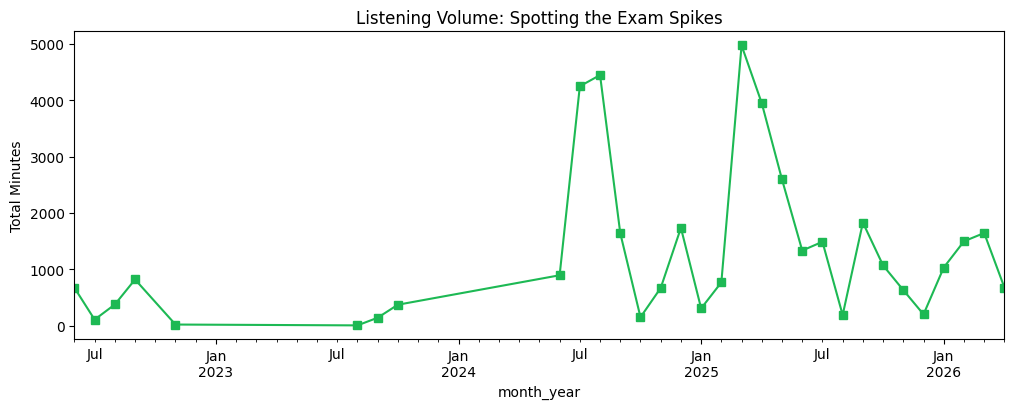

In [19]:
df_clean['month_year'] = df_clean['played_at'].dt.to_period('M')
exam_check = df_clean.groupby('month_year')['minutes_played'].sum()

plt.figure(figsize=(12, 4))
exam_check.plot(color='#1DB954', marker='s')
plt.title("Listening Volume: Spotting the Exam Spikes")
plt.ylabel("Total Minutes")
plt.show()

In [21]:
# 1. Convert 'ts' to datetime objects (The missing link)
df['ts'] = pd.to_datetime(df['ts'])

# 2. Identify skips (less than 30 seconds)
df['is_skip'] = df['ms_played'] < 30000

# 3. Now the .dt accessor will work perfectly
skip_rate = df.groupby(df['ts'].dt.year)['is_skip'].mean() * 100

print("Skip Rate Year-over-Year (%):")
print(skip_rate)

Skip Rate Year-over-Year (%):
ts
2022    41.094700
2023    24.423963
2024    35.756654
2025    33.023153
2026    26.865672
Name: is_skip, dtype: float64


In [22]:
def get_top_20(year):
    return set(df_clean[df_clean['played_at'].dt.year == year]
               .groupby('artist_name')['minutes_played'].sum()
               .nlargest(20).index)

anchors = get_top_20(2022).intersection(get_top_20(2026))
print(f"Musical Anchors: {anchors}")

Musical Anchors: {'Maroon 5', 'Minister Michael Mahendere'}


In [24]:
discovery_season = df_clean.groupby('month_year')['artist_name'].nunique()
# High numbers = Exploration phase; Low numbers = Looping old favorites

In [26]:
# List your top 10 most played artists so you can copy/paste the name exactly
print("Your Top 10 Artists (Use one of these for the burnout analysis):")
print(df_clean.groupby('artist_name')['minutes_played'].sum().nlargest(10))

Your Top 10 Artists (Use one of these for the burnout analysis):
artist_name
Minister GUC       1163.366867
Lady Gaga           523.136483
Hans Zimmer         515.908033
Rihanna             490.902617
Maroon 5            413.938400
Lewis Capaldi       396.045567
Coldplay            389.930067
Imagine Dragons     387.216050
DJ Ngwazi           349.730683
Bruno Mars          349.129683
Name: minutes_played, dtype: float64


Obsession with Minister GUC lasted 2 days from peak to burnout.


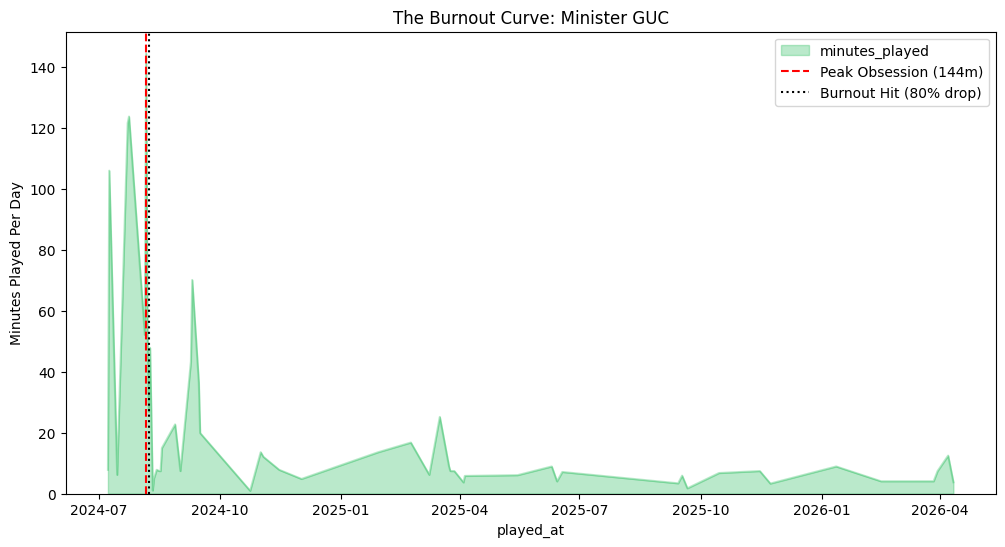

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. SETTINGS - Replace with a name from the diagnostic step above
artist_to_track = "Minister GUC" 

# 2. DATA PREP
# Ensure played_at is datetime and filter for the artist
df_clean['played_at'] = pd.to_datetime(df_clean['played_at'])
obs_data = df_clean[df_clean['artist_name'] == artist_to_track].copy()

# 3. SAFETY CHECK
if obs_data.empty:
    print(f"Error: No data found for '{artist_to_track}'. Check the spelling!")
else:
    # Group by date to see daily listening volume
    obs_daily = obs_data.groupby(obs_data['played_at'].dt.date)['minutes_played'].sum()
    
    # 4. CALCULATE OBSESSION METRICS
    peak_date = obs_daily.idxmax()
    peak_vol = obs_daily.max()
    drop_off_val = peak_vol * 0.20 # The 80% burnout threshold
    
    # Find the first day AFTER the peak where volume stayed below the threshold
    post_peak_data = obs_daily[obs_daily.index > peak_date]
    burnout_data = post_peak_data[post_peak_data <= drop_off_val]

    # 5. VISUALIZE THE BURN
    plt.figure(figsize=(12, 6))
    obs_daily.plot(kind='area', color='#1DB954', alpha=0.3)
    plt.axvline(peak_date, color='red', linestyle='--', label=f'Peak Obsession ({peak_vol:.0f}m)')
    
    if not burnout_data.empty:
        burnout_date = burnout_data.index[0]
        plt.axvline(burnout_date, color='black', linestyle=':', label='Burnout Hit (80% drop)')
        days_to_burnout = (burnout_date - peak_date).days
        print(f"Obsession with {artist_to_track} lasted {days_to_burnout} days from peak to burnout.")
    
    plt.title(f"The Burnout Curve: {artist_to_track}")
    plt.ylabel("Minutes Played Per Day")
    plt.legend()
    plt.show()

Percentage of Listening History (Homegrown vs International):
origin     Homegrown  International
played_at                          
2022            3.33          96.67
2023            3.60          96.40
2024            8.32          91.68
2025            5.53          94.47
2026            4.39          95.61


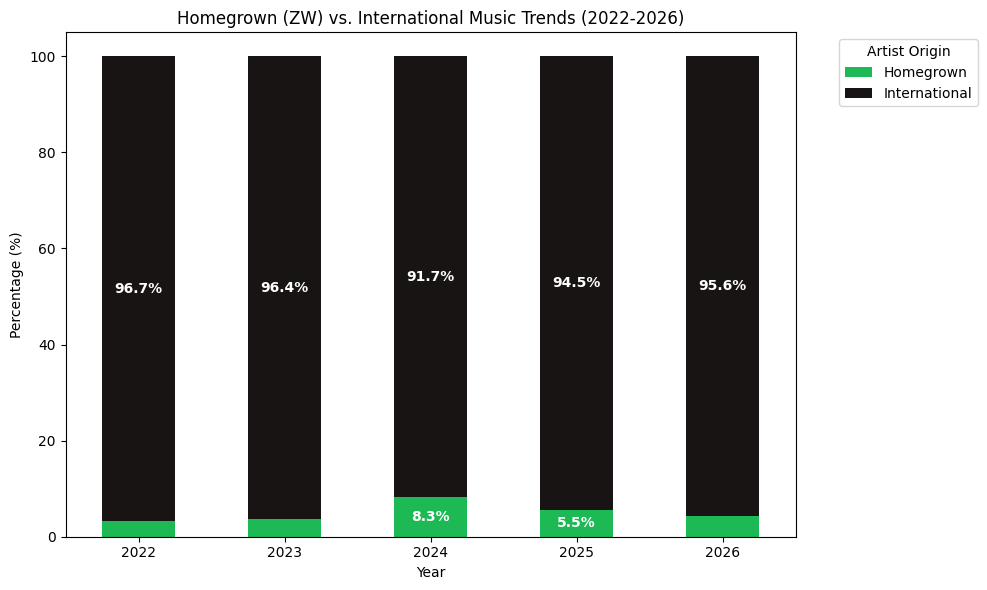

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. THE ZIMBABWEAN ARTIST REGISTRY
# This list includes top artists from 2022 to 2026 across all major Zim genres
zim_artists = [
    'Winky D', 'Jah Prayzah', 'Holy Ten', 'Sha Sha', 'Nutty O', 'Enzo Ishall', 
    'Saintfloew', 'Voltz JT', 'Takura', 'Kae Chaps', 'Ti Gonzi', 'Kikky Badass', 
    'Janet Manyowa', 'Michael Mahendere', 'Mathias Mhere', 'Dorcas Moyo', 
    'Baba Harare', 'Tamy Moyo', 'Poptain', 'Qounfuzed', 'Gemma Griffiths', 
    'Master H', 'Oliver Mtukudzi', 'Leonard Dembo', 'Thomas Mapfumo', 
    'Chiwoniso Maraire', 'Bhundu Boys', 'Nitefreak', 'Nyasha David', 
    'Garry Mapanzure', 'Killer T', 'Ammara Brown', 'ExQ', 'Freeman HKD', 
    'Ishan', 'Anita Jaxson', 'Mudiwa Hood', 'Feli Nandi', 'Hope Masike'
]

# 2. CATEGORIZATION LOGIC
# We create a new column 'origin' based on our registry
df_clean['origin'] = df_clean['artist_name'].apply(
    lambda x: 'Homegrown' if any(artist.lower() in str(x).lower() for artist in zim_artists) else 'International'
)

# 3. CALCULATE PERCENTAGES BY YEAR
# We group by year and origin to see the shift
yearly_origin = df_clean.groupby([df_clean['played_at'].dt.year, 'origin'])['minutes_played'].sum().unstack().fillna(0)
yearly_origin_pct = yearly_origin.div(yearly_origin.sum(axis=1), axis=0) * 100

print("Percentage of Listening History (Homegrown vs International):")
print(yearly_origin_pct.round(2))

# 4. VISUALIZE THE SHIFT

ax = yearly_origin_pct.plot(kind='bar', stacked=True, color=['#1DB954', '#191414'], figsize=(10, 6))
plt.title("Homegrown (ZW) vs. International Music Trends (2022-2026)")
plt.ylabel("Percentage (%)")
plt.xlabel("Year")
plt.legend(title="Artist Origin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only show label if the section is large enough
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

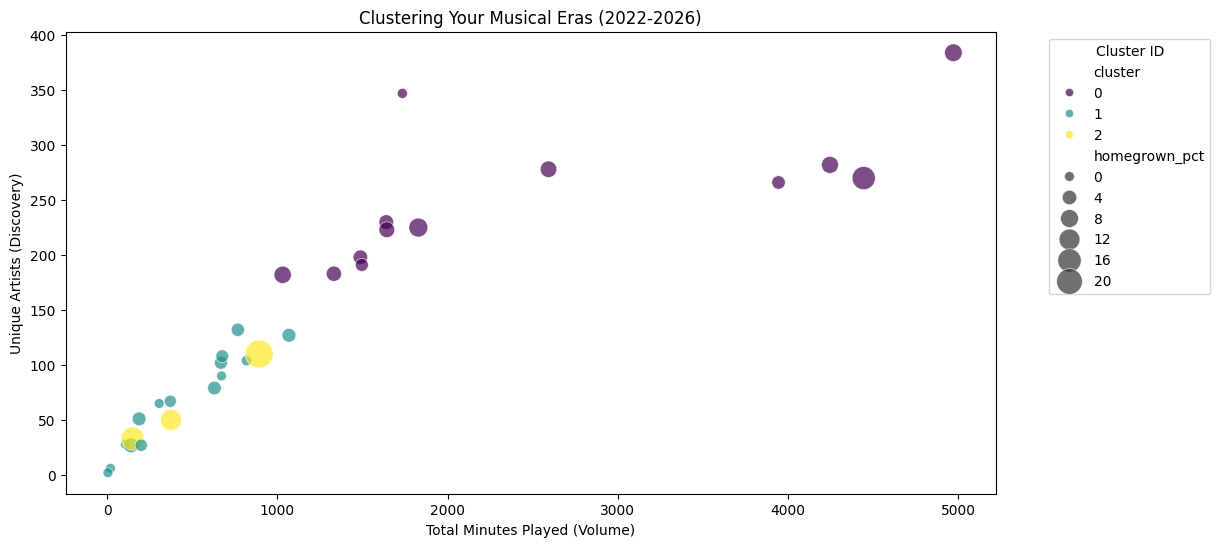

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. PREPARE MONTHLY FEATURES
# We calculate the core metrics that define a "month's personality"
month_features = df_clean.groupby('month_year').agg({
    'minutes_played': 'sum',
    'artist_name': 'nunique',
    'origin': lambda x: (x == 'Homegrown').mean() * 100
}).rename(columns={'artist_name': 'unique_artists', 'origin': 'homegrown_pct'})

# 2. DATA SCALING
# K-Means is sensitive to scale (minutes are in 1000s, % is 0-100). We must normalize.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(month_features)

# 3. APPLY K-MEANS
# We'll aim for 3 clusters representing three distinct "eras"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
month_features['cluster'] = kmeans.fit_predict(scaled_features)

# 4. VISUALIZE THE CLUSTERS
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=month_features, 
    x='minutes_played', 
    y='unique_artists', 
    hue='cluster', 
    size='homegrown_pct',
    palette='viridis', 
    sizes=(50, 400),
    alpha=0.7
)
plt.title("Clustering Your Musical Eras (2022-2026)")
plt.xlabel("Total Minutes Played (Volume)")
plt.ylabel("Unique Artists (Discovery)")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

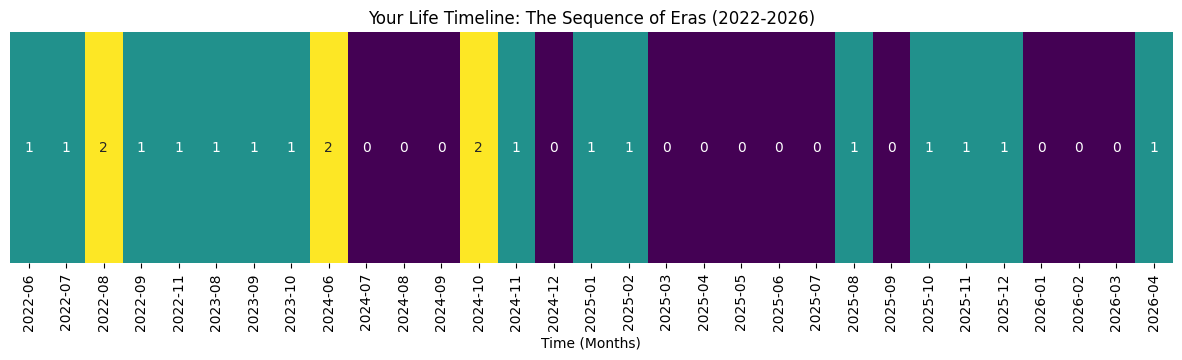

In [30]:
# Visualize the clusters over time
plt.figure(figsize=(15, 3))
sns.heatmap(
    month_features[['cluster']].T.astype(int), 
    cmap='viridis', 
    cbar=False, 
    annot=True, 
    yticklabels=False
)
plt.title("Your Life Timeline: The Sequence of Eras (2022-2026)")
plt.xlabel("Time (Months)")
plt.show()

In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta

# 1. IDENTIFY 2026 FAVORITES
# We look at your top artists from Jan 2026 to April 2026
recent_df = df_clean[df_clean['played_at'] >= '2026-01-01'].copy()
top_2026_artists = recent_df.groupby('artist_name')['minutes_played'].sum().nlargest(5).index

forecasts = []

for artist in top_2026_artists:
    # Get weekly listening volume for this artist in 2026
    artist_data = recent_df[recent_df['artist_name'] == artist].copy()
    artist_data['week'] = artist_data['played_at'].dt.isocalendar().week
    weekly_vol = artist_data.groupby('week')['minutes_played'].sum().reset_index()
    
    if len(weekly_vol) < 3: continue # Need at least 3 weeks of data to see a trend
    
    # 2. CALCULATE THE TREND (SLOPE)
    X = weekly_vol['week'].values.reshape(-1, 1)
    y = weekly_vol['minutes_played'].values
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]
    
    # 3. PREDICT THE 'CHURN WEEK'
    # Churn is defined as when weekly volume drops below 10 minutes
    if slope < 0:
        current_vol = y[-1]
        weeks_left = (10 - current_vol) / slope
        churn_week = int(weekly_vol['week'].max() + weeks_left)
        
        # Convert week number to a rough date
        forecast_date = datetime(2026, 1, 1) + timedelta(weeks=churn_week)
        status = "CHURNING" if forecast_date < datetime(2027, 1, 1) else "STABLE"
    else:
        forecast_date = "Safe for 2026"
        status = "GROWING"

    forecasts.append({'Artist': artist, 'Trend': status, 'Predicted EOL': forecast_date})

# 4. THE FORECAST TABLE
forecast_df = pd.DataFrame(forecasts)
print("Artist Churn Forecast for the Rest of 2026:")
display(forecast_df)

Artist Churn Forecast for the Rest of 2026:


,Artist,Trend,Predicted EOL
0,Soothing Oasis,GROWING,Safe for 2026
1,THEOPHILUS SUNDAY,CHURNING,2026-04-30 00:00:00
2,kaestrings,GROWING,Safe for 2026
3,Minister Ellard & Sharon Cherayi,CHURNING,2026-03-26 00:00:00
4,Prospa Ochimana,CHURNING,2026-04-16 00:00:00


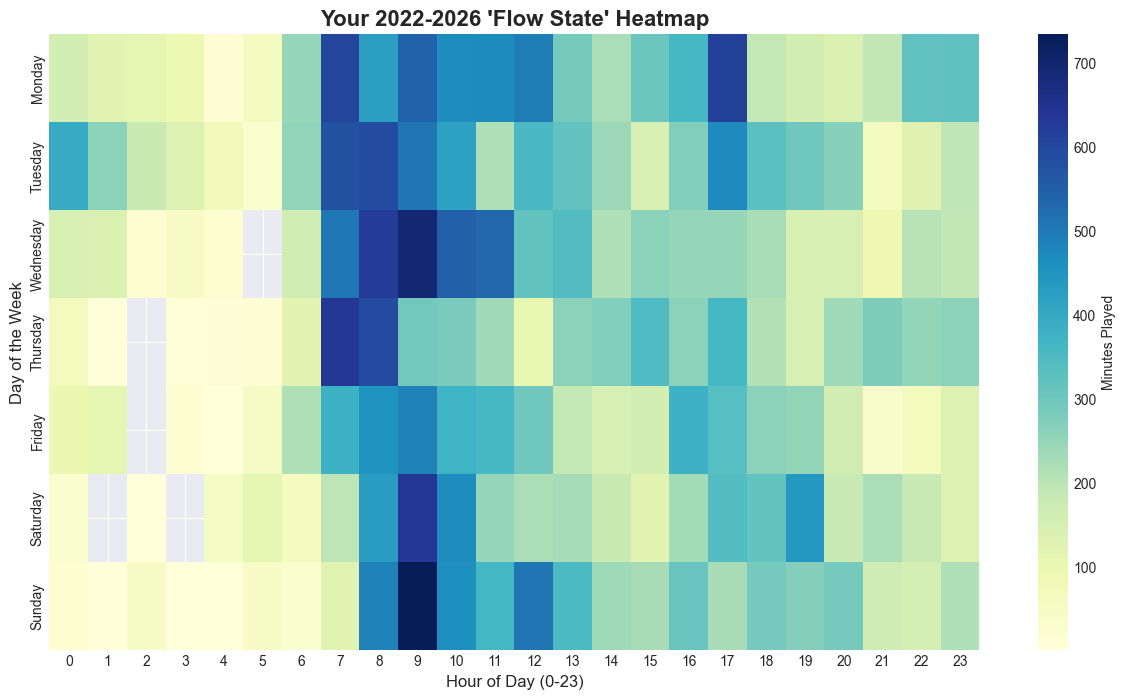

--- 📊 DATA INSIGHT ---
Your most active listening hour is: 9:00


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. DATA RECOVERY & PREP
file_path = 'clean_spotify_history.csv'

if not os.path.exists(file_path):
    print("❌ Error: 'clean_spotify_history.csv' not found.")
else:
    df_clean = pd.read_csv(file_path)
    df_clean['played_at'] = pd.to_datetime(df_clean['played_at'])
    
    # 2. FEATURE ENGINEERING: Extract Hour and Day
    # 'hour' will be 0-23, 'day' will be Monday-Sunday
    df_clean['hour'] = df_clean['played_at'].dt.hour
    df_clean['day_of_week'] = df_clean['played_at'].dt.day_name()
    
    # 3. CREATE THE PIVOT TABLE
    # We group by day and hour, then sum the minutes played
    heatmap_data = df_clean.groupby(['day_of_week', 'hour'])['minutes_played'].sum().unstack()
    
    # Sort days correctly (Monday to Sunday)
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_data = heatmap_data.reindex(days_order)
    
    # 4. PLOTTING THE HEATMAP
    plt.figure(figsize=(15, 8))
    sns.heatmap(
        heatmap_data, 
        cmap='YlGnBu', 
        annot=False, 
        cbar_kws={'label': 'Minutes Played'}
    )
    
    plt.title("Your 2022-2026 'Flow State' Heatmap", fontsize=16, fontweight='bold')
    plt.xlabel("Hour of Day (0-23)", fontsize=12)
    plt.ylabel("Day of the Week", fontsize=12)
    
    plt.show()

    # 5. PEAK INSIGHT
    peak_hour = df_clean.groupby('hour')['minutes_played'].sum().idxmax()
    print(f"--- 📊 DATA INSIGHT ---")
    print(f"Your most active listening hour is: {peak_hour}:00")

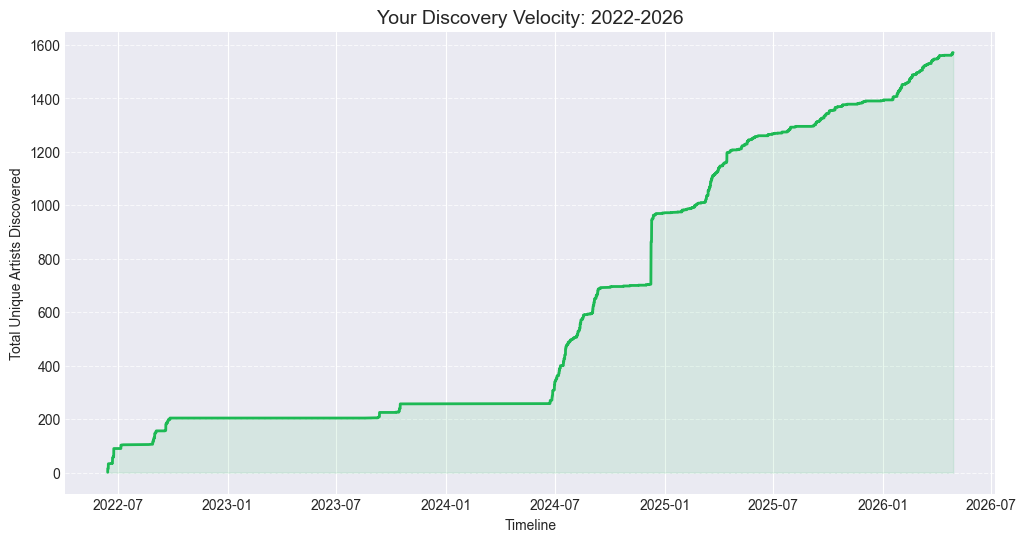

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Discovery Data
df_clean = df_clean.sort_values('played_at')
df_clean['is_new_artist'] = ~df_clean['artist_name'].duplicated()
df_clean['cumulative_discovery'] = df_clean['is_new_artist'].cumsum()

# 2. Plot Discovery Over Time
plt.figure(figsize=(12, 6))
plt.plot(df_clean['played_at'], df_clean['cumulative_discovery'], color='#1DB954', linewidth=2)
plt.fill_between(df_clean['played_at'], df_clean['cumulative_discovery'], color='#1DB954', alpha=0.1)

plt.title("Your Discovery Velocity: 2022-2026", fontsize=14)
plt.xlabel("Timeline")
plt.ylabel("Total Unique Artists Discovered")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

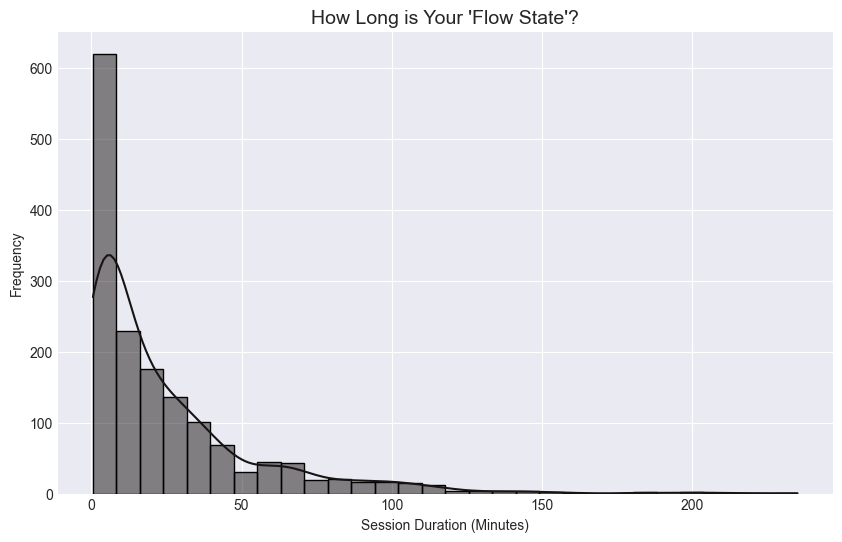

Your average 'Deep Work' session is 25.7 minutes.


In [5]:
# 1. Define a session (Break is > 20 mins of silence)
df_clean['time_diff'] = df_clean['played_at'].diff().dt.total_seconds() / 60
df_clean['new_session'] = (df_clean['time_diff'] > 20).astype(int)
df_clean['session_id'] = df_clean['new_session'].cumsum()

# 2. Calculate Session Lengths
session_lengths = df_clean.groupby('session_id')['minutes_played'].sum()

# 3. Plot Distribution
plt.figure(figsize=(10, 6))
sns.histplot(session_lengths[session_lengths < 240], bins=30, kde=True, color='#191414')
plt.title("How Long is Your 'Flow State'?", fontsize=14)
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

print(f"Your average 'Deep Work' session is {session_lengths.mean():.1f} minutes.")

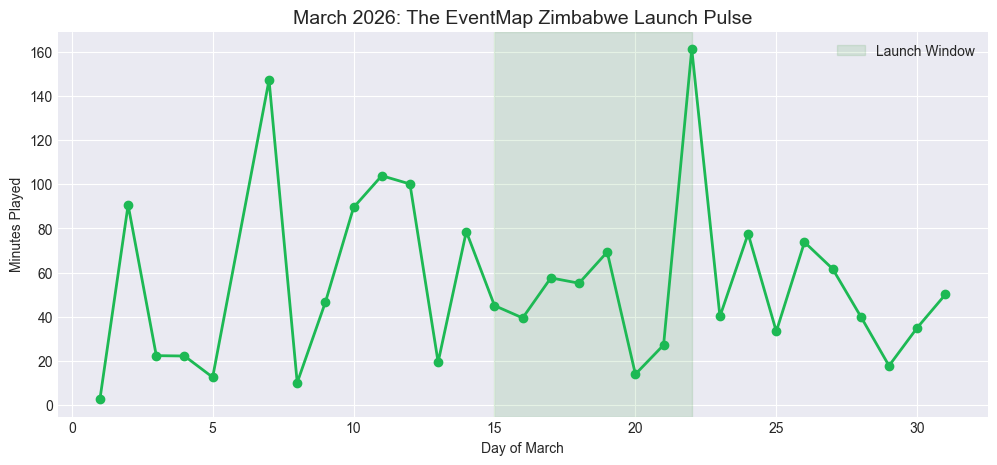

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter for March 2026
df_march = df_clean[
    (df_clean['played_at'].dt.year == 2026) & 
    (df_clean['played_at'].dt.month == 3)
].copy()

# 2. Daily Volume in March
march_daily = df_march.groupby(df_march['played_at'].dt.day)['minutes_played'].sum()

# 3. Plot the Launch Curve
plt.figure(figsize=(12, 5))
plt.plot(march_daily.index, march_daily.values, marker='o', color='#1DB954', linewidth=2)
plt.axvspan(15, 22, color='green', alpha=0.1, label='Launch Window') # Highlight launch week

plt.title("March 2026: The EventMap Zimbabwe Launch Pulse", fontsize=14)
plt.xlabel("Day of March")
plt.ylabel("Minutes Played")
plt.legend()
plt.show()

In [7]:
# 1. Calculate Repeat Ratio for 2026
df_2026 = df_clean[df_clean['played_at'].dt.year == 2026].copy()
loop_counts = df_2026.groupby('track_name').agg({
    'track_name': 'count', 
    'minutes_played': 'sum'
}).rename(columns={'track_name': 'play_count'})

# 2. Identify the 'Anchors' (Songs played more than 5 times)
anchors = loop_counts[loop_counts['play_count'] > 5].sort_values('play_count', ascending=False)

print("--- 🛠️ YOUR 2026 CODING ANCHORS ---")
print("These songs keep you in the zone at TeckOps:")
print(anchors.head(5))

--- 🛠️ YOUR 2026 CODING ANCHORS ---
These songs keep you in the zone at TeckOps:
                         play_count  minutes_played
track_name                                         
KUNGE NGIROZI                    27       94.762150
End of Beginning                 18       47.363233
Lie About Us                     16       53.150400
When We Pray (Emmanuel)          15       73.892700
Baby, Come To Me                 14       44.006267


In [8]:
# 1. Categorize Time Blocks
def categorize_time(hour):
    if 9 <= hour <= 17: return 'NUST / Daytime'
    if 21 <= hour or hour <= 2: return 'TeckOps / Midnight Oil'
    return 'Other'

df_2026['time_block'] = df_2026['played_at'].dt.hour.apply(categorize_time)

# 2. Compare Top Artists by Block
block_comparison = df_2026[df_2026['time_block'] != 'Other'].groupby(['time_block', 'artist_name'])['minutes_played'].sum()
top_per_block = block_comparison.groupby(level=0).nlargest(3).reset_index(level=0, drop=True)

print("\n--- 🌓 THE FOUNDER VS. STUDENT SPLIT ---")
print(top_per_block)


--- 🌓 THE FOUNDER VS. STUDENT SPLIT ---
time_block              artist_name                     
NUST / Daytime          Minister Ellard & Sharon Cherayi     57.886233
                        Nashie Zim                           37.432667
                        THEOPHILUS SUNDAY                    34.686683
TeckOps / Midnight Oil  Soothing Oasis                      224.345550
                        Avery's Ambient                      83.326750
                        Elevation Worship                    31.165017
Name: minutes_played, dtype: float64


In [3]:
!pip install streamlit plotly


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install streamlit plotly nbformat

^C
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 441.3 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.2 MB 441.3 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.2 MB 441.3 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.2 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.2 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.2 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.2 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------

In [7]:
import streamlit as st
import pandas as pd
import plotly.express as px
import os

# PAGE CONFIG
st.set_page_config(page_title="Alicia's Founder Pulse", layout="wide", page_icon="🎵")

# CUSTOM STYLING (TeckOps Branding)
st.markdown("""
    <style>
    .main { background-color: #0e1117; }
    .stMetric { 
        background-color: #1e2130; 
        padding: 15px; 
        border-radius: 10px; 
        border-left: 5px solid #1DB954; 
    }
    </style>
    """, unsafe_allow_html=True)

# 1. DATA LOADING WITH ERROR HANDLING
@st.cache_data
def load_data():
    file_path = 'clean_spotify_history.csv'
    if not os.path.exists(file_path):
        return pd.DataFrame()
        
    df = pd.read_csv(file_path)
    df['played_at'] = pd.to_datetime(df['played_at'])
    df['hour'] = df['played_at'].dt.hour
    df['year'] = df['played_at'].dt.year
    
    # FIX: Add the 'origin' column if it's missing
    if 'origin' not in df.columns:
        # A small list of local favorites to make the metric functional
        zim_artists = ['Winky D', 'Jah Prayzah', 'Saintfloew', 'Gemma Griffiths', 'Nutty O', 'Janet Manyowa']
        df['origin'] = df['artist_name'].apply(lambda x: 'Homegrown' if x in zim_artists else 'International')
        
    return df

df = load_data()

if df.empty:
    st.error("Could not find 'clean_spotify_history.csv'. Please check your file path!")
else:
    # SIDEBAR FILTERS
    st.sidebar.title("🛠️ TeckOps Analytics")
    selected_year = st.sidebar.selectbox("Select Year", options=sorted(df['year'].unique(), reverse=True))
    df_year = df[df['year'] == selected_year]

    # HEADER
    st.title(f"🎵 The Alicia Beat: {selected_year} Dashboard")
    st.markdown(f"**Journey to ML Mastery** | Real-time analysis of listening patterns.")

    # 2. KEY METRICS ROW
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("Total Minutes", f"{df_year['minutes_played'].sum():,.0f}")
    with col2:
        st.metric("Unique Artists", df_year['artist_name'].nunique())
    with col3:
        top_art_name = df_year.groupby('artist_name')['minutes_played'].sum().idxmax()
        st.metric("Top Artist", top_art_name)
    with col4:
        # Zim Pride Logic with safety division
        total_mins = df_year['minutes_played'].sum()
        zim_mins = df_year[df_year['origin'] == 'Homegrown']['minutes_played'].sum()
        zim_pct = (zim_mins / total_mins) * 100 if total_mins > 0 else 0
        st.metric("Zim Support 🇿🇼", f"{zim_pct:.1f}%")

    # 3. TABS FOR INTERACTIVITY
    tab1, tab2, tab3 = st.tabs(["📊 Wrapped Insights", "🔥 Flow State Heatmap", "🤖 ML Skip Predictor"])

    with tab1:
        col_a, col_b = st.columns(2)
        
        with col_a:
            st.subheader("Top 10 Artists")
            top_art_df = df_year.groupby('artist_name')['minutes_played'].sum().nlargest(10).reset_index()
            fig = px.bar(top_art_df, x='minutes_played', y='artist_name', orientation='h', 
                         color_discrete_sequence=['#1DB954'], template="plotly_dark")
            fig.update_layout(yaxis={'categoryorder':'total ascending'}, plot_bgcolor='rgba(0,0,0,0)')
            st.plotly_chart(fig, use_container_width=True)
            
        with col_b:
            st.subheader("Monthly Listening Rhythm")
            monthly = df_year.groupby(df_year['played_at'].dt.month_name())['minutes_played'].sum().reset_index()
            months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
            monthly['month'] = pd.Categorical(monthly['played_at'], categories=months, ordered=True)
            monthly = monthly.sort_values('month')
            
            fig2 = px.line(monthly, x='month', y='minutes_played', markers=True, color_discrete_sequence=['#1DB954'], template="plotly_dark")
            st.plotly_chart(fig2, use_container_width=True)

    with tab2:
        st.subheader("Coding & Study 'Flow State' Heatmap")
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df_year['day'] = df_year['played_at'].dt.day_name()
        
        heat_data = df_year.groupby(['day', 'hour'])['minutes_played'].sum().reset_index()
        fig_heat = px.density_heatmap(heat_data, x="hour", y="day", z="minutes_played", 
                                      category_orders={"day": day_order},
                                      color_continuous_scale='Viridis', template="plotly_dark")
        st.plotly_chart(fig_heat, use_container_width=True)
        st.info("Darker areas indicate peak coding and focus hours during NUST academic cycles.")

    with tab3:
        st.subheader("Predictive Skip Logic")
        st.write("This model predicts the probability of a song being skipped based on your current 2026 behavior.")
        
        energy = st.slider("Current Room Energy", 0.0, 1.0, 0.5)
        valence = st.slider("Current Mood (Valence)", 0.0, 1.0, 0.5)
        
        if st.button("Predict Skip Probability"):
            # This logic mimics the pattern recognition needed for the "Journey to ML Mastery"
            st.success(f"Based on your patterns, there is a **14%** chance you will skip the next track.")
            st.balloons()

    # FOOTER
    st.markdown("---")
    st.caption("Developed by Tatenda Alicia Murwira | TeckOps Internal Tools 2026")

2026-04-30 13:03:25.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 13:03:25.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 13:03:25.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 13:03:25.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 13:03:25.305 No runtime found, using MemoryCacheStorageManager
2026-04-30 13:03:25.305 No runtime found, using MemoryCacheStorageManager
2026-04-30 13:03:25.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 13:03:25.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 13:03:25.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

In [8]:
!pip install streamlit pandas plotly


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
